In [2]:
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

## Задача подготовить таблицу для моделирования:
 - в которой будет влияние станции одной на другую
 - влияние точек интереса на станции
 - столбец с суммарным временем аренды на этой станции за весь период работы станции  

- читаю файл data_additional/station_list.csv

In [2]:
station_list = pd.read_csv('../../data_additional/station_list.csv')
station_list

,station_id,station_name,start_lat,start_lng
0,30200,9th St & Pennsylvania Ave NW,38.894280,-77.023979
1,30201,9th & G St NW,38.898097,-77.023924
2,31000,Eads St & 15th St S,38.858971,-77.053230
3,31001,18th St & S Eads St,38.857250,-77.053320
4,31002,Crystal Dr & 20th St S,38.856425,-77.049232
...,...,...,...,...
908,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605
909,32609,W Columbia St & N Washington St,38.885621,-77.166917
910,32900,Motivate BX Tech office,38.964406,-77.010759
911,32901,6035 Warehouse,38.963810,-77.010266


### Этап 1 - посчитаю влияние одной станции на другую станцию

- оставляю только id станций и точки расположения станций

In [3]:
stations_with_points = station_list[['station_id', 'start_lat', 'start_lng']]
stations_with_points

,station_id,start_lat,start_lng
0,30200,38.894280,-77.023979
1,30201,38.898097,-77.023924
2,31000,38.858971,-77.053230
3,31001,38.857250,-77.053320
4,31002,38.856425,-77.049232
...,...,...,...
908,32608,38.885434,-77.173605
909,32609,38.885621,-77.166917
910,32900,38.964406,-77.010759
911,32901,38.963810,-77.010266


- Код ниже будет расчитывать расстояние между станциями (также указываю в переменной radius 300 метров)

In [9]:
# Переводим в GeoDataFrame (WGS84)
gdf = gpd.GeoDataFrame(
    stations_with_points,
    geometry=gpd.points_from_xy(
        stations_with_points['start_lng'],
        stations_with_points['start_lat']),
        crs="EPSG:4326"
)

# Проецируем в локальную метрическую систему (например, UTM зона, подходящая для вашего региона)
# Здесь для примера – UTM зона 18N (подходит для Вашингтона)
gdf = gdf.to_crs("EPSG:32618")   # метры

# Строим пространственный индекс
sindex = gdf.sindex

# Для каждой точки ищем все точки в радиусе 300 метров (включая саму себя)
radius = 300
matches = []
for idx, row in gdf.iterrows():
    # Создаём буфер
    buffer = row.geometry.buffer(radius)
    # Возможные кандидаты по индексу
    possible_matches_idx = list(sindex.intersection(buffer.bounds))
    # Точная проверка расстояния
    for j in possible_matches_idx:
        if row.geometry.distance(gdf.geometry.iloc[j]) <= radius:
            matches.append((row['station_id'], gdf.iloc[j]['station_id'], row.geometry.distance(gdf.geometry.iloc[j])))

# Результат: пары точек в радиусе 300 м
pairs = pd.DataFrame(matches, columns=['id_center', 'id_neighbor', 'distance_m'])

- вывожу результат

In [10]:
pairs

,id_center,id_neighbor,distance_m
0,30200,31219,224.620881
1,30200,30200,0.000000
2,30200,31270,90.156050
3,30200,31256,256.164646
4,30201,31232,175.403860
...,...,...,...
2054,32901,32901,0.000000
2055,32901,32900,78.760211
2056,33200,31329,201.537068
2057,33200,33200,0.000000


- далее оставляю не повторяющиеся значения в столбцах id_center и id_neighbor

In [11]:
df = pairs[pairs['id_center'] != pairs['id_neighbor']]
df

,id_center,id_neighbor,distance_m
0,30200,31219,224.620881
2,30200,31270,90.156050
3,30200,31256,256.164646
4,30201,31232,175.403860
5,30201,31262,266.008569
...,...,...,...
2049,32608,32605,204.010283
2052,32900,32901,78.760211
2055,32901,32900,78.760211
2056,33200,31329,201.537068


- проверка что нет отрицательных значений

In [12]:
df['distance_m'].min()

np.float64(7.044870890003456)

- далее предварительно собираю id_center и id_neighbor в кортеж и сортирую

In [13]:
df['pair'] = df[['id_center', 'id_neighbor']].apply(lambda x: tuple(sorted(x)), axis=1)

- смотрю что получилось

In [14]:
df

,id_center,id_neighbor,distance_m,pair
0,30200,31219,224.620881,"(30200, 31219)"
2,30200,31270,90.156050,"(30200, 31270)"
3,30200,31256,256.164646,"(30200, 31256)"
4,30201,31232,175.403860,"(30201, 31232)"
5,30201,31262,266.008569,"(30201, 31262)"
...,...,...,...,...
2049,32608,32605,204.010283,"(32605, 32608)"
2052,32900,32901,78.760211,"(32900, 32901)"
2055,32901,32900,78.760211,"(32900, 32901)"
2056,33200,31329,201.537068,"(31329, 33200)"


- затем я удаляю дубликаты

In [15]:
df = df.drop_duplicates(subset='pair')

- смотрю что получилось

In [16]:
df

,id_center,id_neighbor,distance_m,pair
0,30200,31219,224.620881,"(30200, 31219)"
2,30200,31270,90.156050,"(30200, 31270)"
3,30200,31256,256.164646,"(30200, 31256)"
4,30201,31232,175.403860,"(30201, 31232)"
5,30201,31262,266.008569,"(30201, 31262)"
...,...,...,...,...
1975,32278,32280,286.730063,"(32278, 32280)"
2005,32407,32415,255.755518,"(32407, 32415)"
2040,32602,32603,268.786188,"(32602, 32603)"
2046,32605,32608,204.010283,"(32605, 32608)"


- смотрю сколько осталось уникальных id_center

In [17]:
len(df['id_center'].unique())

229

- создаю переменную lambda_ для формулы np.exp(-df['distance_m'] / lambda_)

In [18]:
lambda_ = 300

- рассчитываю влияние одной станции на другую

In [19]:
df['influence'] = np.exp(-df['distance_m'] / lambda_)

- смотрю результат который получился после расчета influence

In [20]:
df

,id_center,id_neighbor,distance_m,pair,influence
0,30200,31219,224.620881,"(30200, 31219)",0.472964
2,30200,31270,90.156050,"(30200, 31270)",0.740433
3,30200,31256,256.164646,"(30200, 31256)",0.425759
4,30201,31232,175.403860,"(30201, 31232)",0.557284
5,30201,31262,266.008569,"(30201, 31262)",0.412015
...,...,...,...,...,...
1975,32278,32280,286.730063,"(32278, 32280)",0.384517
2005,32407,32415,255.755518,"(32407, 32415)",0.426340
2040,32602,32603,268.786188,"(32602, 32603)",0.408218
2046,32605,32608,204.010283,"(32605, 32608)",0.506600


- смотрю как получились рассчеты (influence должно быть в диапазоне от 0 до 1)

In [22]:
df['influence'].describe()

count    342.000000
mean       0.483876
std        0.100301
min        0.368157
25%        0.408003
50%        0.460486
75%        0.536523
max        0.976791
Name: influence, dtype: float64

- завершаю расчеты influence

In [23]:
result = df.groupby('id_center')['influence'].sum().reset_index()
result

,id_center,influence
0,30200,1.639156
1,30201,2.007680
2,31000,1.064608
3,31001,0.600891
4,31002,0.417648
...,...,...
224,32278,0.384517
225,32407,0.426340
226,32602,0.408218
227,32605,0.506600


- смотрю финальный результат

In [24]:
result['influence'].describe()

count    229.000000
mean       0.722645
std        0.415815
min        0.368750
25%        0.424390
50%        0.536722
75%        0.912364
max        2.524763
Name: influence, dtype: float64

- вывел отсортированный dataframe по influence

In [25]:
result.sort_values(by='influence', ascending=False)

,id_center,influence
69,31208,2.524763
66,31204,2.410024
76,31216,2.098553
98,31254,2.075791
1,30201,2.007680
...,...,...
7,31011,0.375765
149,31604,0.373556
176,31817,0.373196
140,31519,0.370698


- проверяю есть ли эти станции в исходном dataframe

In [28]:
station_list[station_list['station_id'].isin([31208, 31615, 31011])]

,station_id,station_name,start_lat,start_lng
13,31011,Crystal Dr & 23rd St S,38.852929,-77.049723
181,31208,M St & New Jersey Ave SE,38.876300,-77.003700
440,31615,6th & H St NE,38.899972,-76.998347


- добавляю столбец influence в таблицу station_list

In [30]:
station_list_influence = station_list.join(result, how='left', lsuffix='_')
station_list_influence

,station_id,station_name,start_lat,start_lng,id_center,influence
0,30200,9th St & Pennsylvania Ave NW,38.894280,-77.023979,30200.0,1.639156
1,30201,9th & G St NW,38.898097,-77.023924,30201.0,2.007680
2,31000,Eads St & 15th St S,38.858971,-77.053230,31000.0,1.064608
3,31001,18th St & S Eads St,38.857250,-77.053320,31001.0,0.600891
4,31002,Crystal Dr & 20th St S,38.856425,-77.049232,31002.0,0.417648
...,...,...,...,...,...,...
908,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605,NaN,NaN
909,32609,W Columbia St & N Washington St,38.885621,-77.166917,NaN,NaN
910,32900,Motivate BX Tech office,38.964406,-77.010759,NaN,NaN
911,32901,6035 Warehouse,38.963810,-77.010266,NaN,NaN


- удаляю столбец id_center

In [31]:
station_list_influence.drop(columns='id_center', inplace=True)

- вывожу что получилось

In [32]:
station_list_influence

,station_id,station_name,start_lat,start_lng,influence
0,30200,9th St & Pennsylvania Ave NW,38.894280,-77.023979,1.639156
1,30201,9th & G St NW,38.898097,-77.023924,2.007680
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608
3,31001,18th St & S Eads St,38.857250,-77.053320,0.600891
4,31002,Crystal Dr & 20th St S,38.856425,-77.049232,0.417648
...,...,...,...,...,...
908,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605,NaN
909,32609,W Columbia St & N Washington St,38.885621,-77.166917,NaN
910,32900,Motivate BX Tech office,38.964406,-77.010759,NaN
911,32901,6035 Warehouse,38.963810,-77.010266,NaN


- заменяю NaN на 0, потому что где есть NaN там нет влияния одной станции на другую

In [38]:
station_list_influence['influence'] = station_list_influence['influence'].fillna(0)

- смотрю результат

In [39]:
station_list_influence

,station_id,station_name,start_lat,start_lng,influence
0,30200,9th St & Pennsylvania Ave NW,38.894280,-77.023979,1.639156
1,30201,9th & G St NW,38.898097,-77.023924,2.007680
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608
3,31001,18th St & S Eads St,38.857250,-77.053320,0.600891
4,31002,Crystal Dr & 20th St S,38.856425,-77.049232,0.417648
...,...,...,...,...,...
908,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885434,-77.173605,0.000000
909,32609,W Columbia St & N Washington St,38.885621,-77.166917,0.000000
910,32900,Motivate BX Tech office,38.964406,-77.010759,0.000000
911,32901,6035 Warehouse,38.963810,-77.010266,0.000000


- меняю типы данных для записи dataframe в parquet

In [41]:
station_list_influence = station_list_influence.astype(
    {
        'station_id':'int32', 
        'station_name': 'object',
        'start_lat': 'float32',
        'start_lng': 'float32',
        'influence': 'float32'
    }
)

- записываю dataframe в файл с расширение parquet

In [42]:
table_for_parquet = pa.Table.from_pandas(station_list_influence)

In [43]:
pq.write_table(table_for_parquet, '../../data_after_preprocessing/1_station_list_influence.parquet')

### Этап 2 - посчитаю влияние точек интереса на станцию

- читаю файл data_after_preprocessing/1_station_list_influence.parquet

In [2]:
station_list_influence = pd.read_parquet('../../data_after_preprocessing/1_station_list_influence.parquet')
station_list_influence

,station_id,station_name,start_lat,start_lng,influence
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
1,30201,9th & G St NW,38.898098,-77.023926,2.007680
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648
...,...,...,...,...,...
908,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000
909,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000
910,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000
911,32901,6035 Warehouse,38.963810,-77.010269,0.000000


- меняю название столбца station_id на start_station_id, что бы потом сделать merge

In [3]:
station_list_influence = station_list_influence.rename(columns={'station_id': 'start_station_id'})

- читаю dataframe где есть данные о зданиях вокруг станций в радиусе 300 метров

In [4]:
point_of_interest = pd.read_csv('../../data_additional/point_of_interest.csv')
point_of_interest

,start_station_id,category,name_build,start_lat,start_lng
0,30200,place_of_worship,Methodist Protestant Church,38.896501,-77.024143
1,30200,kindergarten,Georgetown Hill Early Childhood Center,38.895100,-77.023200
2,30200,kindergarten,Just Us Kids Child Development Center,38.894600,-77.020700
3,30200,theatre,Shakespeare Theatre Company - Klein Theater,38.895734,-77.022132
4,30200,cafe,Gregorys Coffee,38.895972,-77.021713
...,...,...,...,...,...
34392,33200,bench,NaN,38.894267,-77.038270
34393,33200,bench,NaN,38.897443,-77.036620
34394,33200,bench,NaN,38.897445,-77.036499
34395,33200,bench,NaN,38.896953,-77.036979


- делаю pivot_table что получить столбцы по все категориям и для каждой станции

In [5]:
station_features = point_of_interest.pivot_table(
    index='start_station_id',
    columns='category',
    aggfunc='size',
    fill_value=0
).reset_index()

- вывожу результат

In [6]:
station_features

category,start_station_id,animal_boarding,animal_shelter,archive,arts_centre,atm,bank,bar,bbq,bell,...,training,tutor,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place
0,30200,0,0,0,1,1,7,4,0,0,...,0,0,0,0,0,0,0,10,0,0
1,30201,0,0,0,0,2,6,7,0,0,...,0,0,0,0,0,2,0,5,0,0
2,31000,1,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,31001,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,31002,0,0,0,0,0,2,2,0,0,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,32608,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
792,32609,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
793,32900,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
794,32901,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


- сразу подготовлю столбец total_builds

In [7]:
station_features['total_builds'] = station_features.loc[:, 'animal_boarding':].sum(axis=1)

- запишу сразу в словарь для дальнейшего использования

In [8]:
total_builds_dict = station_features.set_index("start_station_id")["total_builds"].to_dict()

- написал функцию для расчета расстояния между станции и различными знаниями

In [9]:
def haversine_meters(lat1, lon1, lat2, lon2):
    R = 6371000  # метры

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

- надо собрать все в один dataframe

In [10]:
df = point_of_interest.merge(station_list_influence, on='start_station_id', suffixes=('_b', '_s'))

- вывожу результат

In [11]:
df

,start_station_id,category,name_build,start_lat_b,start_lng_b,station_name,start_lat_s,start_lng_s,influence
0,30200,place_of_worship,Methodist Protestant Church,38.896501,-77.024143,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
1,30200,kindergarten,Georgetown Hill Early Childhood Center,38.895100,-77.023200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
2,30200,kindergarten,Just Us Kids Child Development Center,38.894600,-77.020700,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
3,30200,theatre,Shakespeare Theatre Company - Klein Theater,38.895734,-77.022132,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
4,30200,cafe,Gregorys Coffee,38.895972,-77.021713,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156
...,...,...,...,...,...,...,...,...,...
43382,33200,bench,NaN,38.894267,-77.038270,17th St & New York Ave NW,38.896603,-77.039780,0.000000
43383,33200,bench,NaN,38.897443,-77.036620,17th St & New York Ave NW,38.896603,-77.039780,0.000000
43384,33200,bench,NaN,38.897445,-77.036499,17th St & New York Ave NW,38.896603,-77.039780,0.000000
43385,33200,bench,NaN,38.896953,-77.036979,17th St & New York Ave NW,38.896603,-77.039780,0.000000


- расчитываю расстояние между станциями и зданиями

In [12]:
df['distance_m'] = haversine_meters(
    df['start_lat_b'], df['start_lng_b'],
    df['start_lat_s'], df['start_lng_s']
)

- вывожу distance_m что бы посмотреть что дистанция до 300 метров

In [13]:
df['distance_m'].describe()

count    43387.000000
mean       181.661034
std         80.679336
min          0.029649
25%        121.717269
50%        193.277184
75%        250.378367
max        300.597027
Name: distance_m, dtype: float64

- расчитываю влияние

In [14]:
lambda_ = 300

In [15]:
df['influence_build'] = np.exp(-df['distance_m'] / lambda_)

In [16]:
df

,start_station_id,category,name_build,start_lat_b,start_lng_b,station_name,start_lat_s,start_lng_s,influence,distance_m,influence_build
0,30200,place_of_worship,Methodist Protestant Church,38.896501,-77.024143,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,247.325077,0.438491
1,30200,kindergarten,Georgetown Hill Early Childhood Center,38.895100,-77.023200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,113.540748,0.684909
2,30200,kindergarten,Just Us Kids Child Development Center,38.894600,-77.020700,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,286.238424,0.385148
3,30200,theatre,Shakespeare Theatre Company - Klein Theater,38.895734,-77.022132,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,227.534565,0.468393
4,30200,cafe,Gregorys Coffee,38.895972,-77.021713,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,271.975888,0.403901
...,...,...,...,...,...,...,...,...,...,...,...
43382,33200,bench,NaN,38.894267,-77.038270,17th St & New York Ave NW,38.896603,-77.039780,0.000000,290.697315,0.379466
43383,33200,bench,NaN,38.897443,-77.036620,17th St & New York Ave NW,38.896603,-77.039780,0.000000,288.969845,0.381657
43384,33200,bench,NaN,38.897445,-77.036499,17th St & New York Ave NW,38.896603,-77.039780,0.000000,299.040775,0.369058
43385,33200,bench,NaN,38.896953,-77.036979,17th St & New York Ave NW,38.896603,-77.039780,0.000000,245.489145,0.441182


- проверяю коректность результатов

In [17]:
df['influence_build'].describe()

count    43387.000000
mean         0.566582
std          0.161233
min          0.367148
25%          0.434050
50%          0.525052
75%          0.666494
max          0.999901
Name: influence_build, dtype: float64

In [18]:
result = df.groupby(['start_station_id', 'category'])['influence_build'].sum().reset_index()
result

,start_station_id,category,influence_build
0,30200,arts_centre,0.457629
1,30200,atm,0.372088
2,30200,bank,4.139420
3,30200,bar,1.863055
4,30200,bench,2.520256
...,...,...,...
8923,33200,pharmacy,0.527011
8924,33200,post_office,0.403813
8925,33200,restaurant,0.946972
8926,33200,school,0.492013


- смотрю результат для для станции 30200

In [19]:
result[result['start_station_id'] == 30200]

,start_station_id,category,influence_build
0,30200,arts_centre,0.457629
1,30200,atm,0.372088
2,30200,bank,4.139420
3,30200,bar,1.863055
4,30200,bench,2.520256
5,30200,bicycle_parking,1.790253
6,30200,bicycle_rental,2.608462
7,30200,cafe,2.104712
8,30200,charging_station,0.460407
9,30200,drinking_water,0.703141


- делаю pivot_table что бы сделать вывод иформации более читаемым

In [20]:
part_df_for_modeling = result.pivot_table(
    index='start_station_id',
    columns='category',
    values='influence_build',
    fill_value=0
).reset_index()

- вывожу результат

In [21]:
part_df_for_modeling

category,start_station_id,animal_boarding,animal_shelter,archive,arts_centre,atm,bank,bar,bbq,bell,...,training,tutor,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place
0,30200,0.000000,0.0,0.0,0.457629,0.372088,4.139420,1.863055,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0
1,30201,0.000000,0.0,0.0,0.000000,0.818954,2.511669,3.585489,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0
2,31000,0.544705,0.0,0.0,0.000000,0.000000,1.010249,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0
3,31001,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0
4,31002,0.000000,0.0,0.0,0.000000,0.000000,1.061388,1.157652,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,32608,0.000000,0.0,0.0,0.000000,0.419969,0.455282,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0
792,32609,0.544646,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
793,32900,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
794,32901,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0


- делаю слияние station_list_influence с таблицей part_df_for_modeling

In [22]:
station_list_influence_full = station_list_influence.merge(part_df_for_modeling, on='start_station_id')
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,training,tutor,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,0.0,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
901,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
902,32901,6035 Warehouse,38.963810,-77.010269,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0


- добавляю столбец total_builds в dataframe station_list_influence_full

In [23]:
station_list_influence_full['total_builds'] = station_list_influence_full['start_station_id'].map(total_builds_dict)

- смотрю что получилось

In [24]:
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,tutor,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0,92
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0,140
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0,59
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0,31
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0,34
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13
901,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4
902,32901,6035 Warehouse,38.963810,-77.010269,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4


- записываю dataframe в parquet

In [25]:
table_for_parquet = pa.Table.from_pandas(station_list_influence_full)

In [26]:
pq.write_table(table_for_parquet, '../../data_after_preprocessing/2_station_list_influence_full.parquet')

### Этап 3 - добавление столбцов

- 1. duration_in_minutes 
- 2. pickup
- 3. dropoff

- читаю файл data_after_preprocessing/2_station_list_influence_full.parquet

In [3]:
station_list_influence_full = pd.read_parquet('../../data_after_preprocessing/2_station_list_influence_full.parquet')
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,tutor,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0,92
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0,140
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0,59
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0,31
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0,34
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13
901,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4
902,32901,6035 Warehouse,38.963810,-77.010269,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4


- читаю файл data_after_preprocessing/daily_rent_detail.parquet

In [4]:
daily_rent_detail = pd.read_parquet('../../data_after_preprocessing/daily_rent_detail.parquet')
daily_rent_detail

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_in_minutes
0,946D42AD89539210,docked_bike,2020-05-30 17:25:29.000,2020-05-31 18:25:22.000,Anacostia Library,31804,11th & H St NE,31614,38.865784,-76.978401,38.899982,-76.991386,casual,1499.883301
1,CC46FAAB662B8613,docked_bike,2020-05-09 14:42:04.000,2020-05-09 15:06:33.000,10th & E St NW,31256,21st St & Constitution Ave NW,31261,38.895912,-77.026062,38.892460,-77.046570,member,24.483334
2,72F00B2FB833D6ED,docked_bike,2020-05-24 17:27:19.000,2020-05-24 17:43:51.000,Connecticut Ave & Newark St NW / Cleveland Park,31305,12th & U St NW,31268,38.934265,-77.057976,38.916786,-77.028137,member,16.533333
3,4DFBE6AED989DF35,docked_bike,2020-05-27 15:29:52.000,2020-05-27 15:47:13.000,Connecticut Ave & Newark St NW / Cleveland Park,31305,14th & Belmont St NW,31119,38.934265,-77.057976,38.921074,-77.031883,casual,17.350000
4,1AAFE6B4331AB9DF,docked_bike,2020-05-31 14:06:03.000,2020-05-31 14:30:30.000,Georgia Ave & Morton St NW,31419,17th & K St NW,31213,38.932129,-77.023499,38.902760,-77.038628,casual,24.450001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16086667,117C27DBDD138B72,electric_bike,2024-08-01 08:10:22.293,2024-08-01 08:10:37.641,NaN,0,NaN,0,38.889999,-77.000000,38.889999,-77.000000,member,0.255800
16086668,4774F4D630258482,electric_bike,2024-08-08 10:05:21.938,2024-08-08 10:21:46.654,NaN,0,NaN,0,38.900002,-77.000000,38.869999,-76.949997,member,16.411934
16086669,D75836E25E77B5EC,electric_bike,2024-08-03 16:29:32.252,2024-08-03 16:35:43.179,NaN,0,NaN,0,38.919998,-76.989998,38.919998,-77.000000,member,6.182117
16086670,3B888603D18116DC,electric_bike,2024-08-03 02:49:45.661,2024-08-03 02:59:56.877,NaN,0,NaN,0,38.919998,-77.019997,38.919998,-77.029999,member,10.186934


- добавляю столбец date

In [5]:
daily_rent_detail['date'] = daily_rent_detail['started_at'].dt.date

- делаю группировку по столбцам start_station_id, date и считаю duration_in_minutes суммарное количество минут

In [6]:
stations_work_day = daily_rent_detail.groupby(['start_station_id', 'date'])['duration_in_minutes'].sum().reset_index()
stations_work_day

,start_station_id,date,duration_in_minutes
0,0,2020-06-17,47.799999
1,0,2020-06-18,116.266663
2,0,2020-06-19,5.516667
3,0,2020-06-29,15.233334
4,0,2020-07-01,114.516663
...,...,...,...
874628,33200,2024-08-27,481.353180
874629,33200,2024-08-28,271.895111
874630,33200,2024-08-29,195.191528
874631,33200,2024-08-30,748.604675


- считаю сколько работала каждая станция в днях

In [11]:
station_work_days = stations_work_day.groupby('start_station_id')['date'].count().to_dict()

- добавляю столбец station_work_days

In [12]:
station_list_influence_full['station_work_days'] = station_list_influence_full['start_station_id'].map(station_work_days)

- вывожу результат

In [15]:
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,university,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0,92,576
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0,140,577
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0,59,1499
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0,31,445
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0,65,1548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0,34,943
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13,1119
901,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4,50
902,32901,6035 Warehouse,38.963810,-77.010269,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4,347


- убираю станцию, которая равна 0 (у которых отсутствуют данные)

In [16]:
stations_work_day = stations_work_day[stations_work_day['start_station_id'] != 0]

- создаю словарь

In [17]:
work_of_year = {}

- делаю расчеты для каждой станции (делаю подсчет суммарного количества аренды в минутах)

In [18]:
for station_id in stations_work_day['start_station_id'].unique():
    minuts = stations_work_day[stations_work_day['start_station_id'] == station_id]['duration_in_minutes'].rolling(365).sum().median()
    work_of_year[station_id] = round(minuts, 2)

- добавляю столбец duration_in_minutes

In [19]:
station_list_influence_full['duration_in_minutes'] = station_list_influence_full['start_station_id'].map(work_of_year)

- смотрю describe по столбцу duration_in_minutes

In [20]:
station_list_influence_full['duration_in_minutes'].describe()

count    7.850000e+02
mean     1.234240e+05
std      1.674574e+05
min      9.110100e+03
25%      3.318534e+04
50%      5.833535e+04
75%      1.606943e+05
max      1.761587e+06
Name: duration_in_minutes, dtype: float64

- вывожу результат

In [21]:
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,duration_in_minutes
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0,92,576,300402.16
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0,140,577,262976.84
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0,59,1499,92717.80
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0,31,445,127993.77
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0,65,1548,112651.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0,34,943,24557.68
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13,1119,24903.63
901,32900,Motivate BX Tech office,38.964405,-77.010757,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4,50,NaN
902,32901,6035 Warehouse,38.963810,-77.010269,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,4,347,NaN


- заменяю Nan в столбце duration_in_minutes

In [22]:
station_list_influence_full['duration_in_minutes'] = station_list_influence_full['duration_in_minutes'].replace({np.nan: 0})

- убираю нули из столбца duration_in_minutes

In [23]:
station_list_influence_full = station_list_influence_full[station_list_influence_full['duration_in_minutes'] != 0]

- вывожу результат

In [24]:
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vacuum_cleaner,vehicle_inspection,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,duration_in_minutes
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.0,0.0,0.000000,0.000000,6.073279,0.0,0.0,92,576,300402.16
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,0.0,0.0,1.074973,0.000000,3.120470,0.0,0.0,140,577,262976.84
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.548516,0.0,0.0,59,1499,92717.80
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.569035,0.0,0.0,31,445,127993.77
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.699214,0.410945,0.0,0.0,65,1548,112651.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,32606,N Roosevelt St & Roosevelt Blvd,38.878086,-77.153954,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,1,1263,25225.78
898,32607,S Maple Ave & S Washington St,38.879719,-77.178406,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,14,1169,30795.18
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.0,0.0,0.000000,0.000000,0.655027,0.0,0.0,34,943,24557.68
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,13,1119,24903.63


- читаю файл bike_share/usage_frequency.csv

In [25]:
usage_frequency = pd.read_csv('../../bike_share/usage_frequency.csv')
usage_frequency

,date,station_name,pickup_counts,dropoff_counts
0,2020-05-01,10th & E St NW,11,7.0
1,2020-05-01,10th & Florida Ave NW,8,8.0
2,2020-05-01,10th & G St NW,3,2.0
3,2020-05-01,10th & K St NW,12,15.0
4,2020-05-01,10th & Monroe St NE,5,6.0
...,...,...,...,...
873313,2024-08-31,Wisconsin Ave & Upton St NW,28,26.0
873314,2024-08-31,Woodglen Dr & Executive Blvd,4,1.0
873315,2024-08-31,Woodley Park Metro / Calvert St & Connecticut ...,34,34.0
873316,2024-08-31,Woodmont Ave & Strathmore St,10,7.0


- делаю группировку по столбцу station_name и считаю сумму pickup_counts, dropoff_counts

In [27]:
group_usage_frequency = usage_frequency.groupby('station_name')[['pickup_counts', 'dropoff_counts']].sum()
group_usage_frequency

,pickup_counts,dropoff_counts
station_name,,
S Scott St & 13th St S,429,419.0
10th & E St NW,43545,48318.0
10th & Florida Ave NW,25539,25382.0
10th & G St NW,31089,39360.0
10th & H St NE,23583,24170.0
...,...,...
Woodglen Dr & Executive Blvd,3126,2939.0
Woodley Park Metro / Calvert St & Connecticut Ave NW,47071,38240.0
Woodmont Ave & Strathmore St,10862,9833.0


- записываю данные о станции в словарь 

In [32]:
pickup = group_usage_frequency['pickup_counts'].to_dict()
pickup

{' S Scott St & 13th St S': 429,
 '10th & E St NW': 43545,
 '10th & Florida Ave NW': 25539,
 '10th & G St NW': 31089,
 '10th & H St NE': 23583,
 '10th & K St NW': 54363,
 '10th & Monroe St NE': 16049,
 '10th & Quincy St NE / Turkey Thicket Rec': 5601,
 '10th & Rhode Island Ave NE': 1,
 '10th & U St NW': 37554,
 '10th St & Constitution Ave NW': 47491,
 '10th St & Florida Ave NW': 32264,
 "10th St & L'Enfant Plaza SW": 30222,
 '10th St & Rhode Island Ave NE': 3937,
 '10th St & Spring Rd NW': 8185,
 '11th & C St SE': 27846,
 '11th & Clifton St NW': 21477,
 '11th & F St NW': 25311,
 '11th & Girard St NW': 56054,
 '11th & H St NE': 9212,
 '11th & Kenyon St NW': 68702,
 '11th & M St NW': 99763,
 '11th & O St NW': 61932,
 '11th & Park Rd NW': 47462,
 '11th & S St NW': 55939,
 '11th & V St NW': 21506,
 '11th & V st NW': 8763,
 '12th & Irving St NE': 10754,
 '12th & L St NW': 51583,
 '12th & Newton St NE': 6765,
 '12th & U St NW': 36311,
 '12th & Varnum St NE': 1403,
 '12th St & New York Ave NW

- записываю данные о станции в словарь

In [33]:
dropoff = group_usage_frequency['dropoff_counts'].to_dict()
dropoff

{' S Scott St & 13th St S': 419.0,
 '10th & E St NW': 48318.0,
 '10th & Florida Ave NW': 25382.0,
 '10th & G St NW': 39360.0,
 '10th & H St NE': 24170.0,
 '10th & K St NW': 54747.0,
 '10th & Monroe St NE': 13051.0,
 '10th & Quincy St NE / Turkey Thicket Rec': 5464.0,
 '10th & Rhode Island Ave NE': 1.0,
 '10th & U St NW': 37587.0,
 '10th St & Constitution Ave NW': 51533.0,
 '10th St & Florida Ave NW': 30969.0,
 "10th St & L'Enfant Plaza SW": 28707.0,
 '10th St & Rhode Island Ave NE': 3572.0,
 '10th St & Spring Rd NW': 6181.0,
 '11th & C St SE': 27545.0,
 '11th & Clifton St NW': 16171.0,
 '11th & F St NW': 30408.0,
 '11th & Girard St NW': 47968.0,
 '11th & H St NE': 9417.0,
 '11th & Kenyon St NW': 46835.0,
 '11th & M St NW': 97127.0,
 '11th & O St NW': 56157.0,
 '11th & Park Rd NW': 39278.0,
 '11th & S St NW': 53955.0,
 '11th & V St NW': 20855.0,
 '11th & V st NW': 7307.0,
 '12th & Irving St NE': 10057.0,
 '12th & L St NW': 50238.0,
 '12th & Newton St NE': 6256.0,
 '12th & U St NW': 3362

- добавляю столбец pickup в station_list_influence_full

In [37]:
station_list_influence_full['pickup'] = station_list_influence_full['station_name'].map(pickup)

- добавляю столбец dropoff в station_list_influence_full

In [38]:
station_list_influence_full['dropoff'] = station_list_influence_full['station_name'].map(dropoff)

- удаляю столбец duration_in_minutes, что бы потом поставить его в конец

In [40]:
duration_in_minutes = station_list_influence_full.pop('duration_in_minutes')

In [41]:
duration_in_minutes

0      300402.16
1      262976.84
2       92717.80
3      127993.77
4      112651.08
         ...    
897     25225.78
898     30795.18
899     24557.68
900     24903.63
903    187200.37
Name: duration_in_minutes, Length: 785, dtype: float64

- возвращаяю его назад

In [42]:
station_list_influence_full['duration_in_minutes'] = duration_in_minutes

- вывожу результат

In [43]:
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,pickup,dropoff,duration_in_minutes
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.000000,0.000000,6.073279,0.0,0.0,92,576,18950.0,24277.0,300402.16
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,1.074973,0.000000,3.120470,0.0,0.0,140,577,20376.0,22235.0,262976.84
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.548516,0.0,0.0,59,1499,12849.0,12781.0,92717.80
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.569035,0.0,0.0,31,445,2272.0,2222.0,127993.77
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.699214,0.410945,0.0,0.0,65,1548,18701.0,19036.0,112651.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,32606,N Roosevelt St & Roosevelt Blvd,38.878086,-77.153954,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,1,1263,3285.0,2998.0,25225.78
898,32607,S Maple Ave & S Washington St,38.879719,-77.178406,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,14,1169,2598.0,2461.0,30795.18
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.000000,0.000000,0.655027,0.0,0.0,34,943,2058.0,1832.0,24557.68
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,13,1119,2410.0,2077.0,24903.63


- записываю dataframe в parquet

In [44]:
table_for_parquet = pa.Table.from_pandas(station_list_influence_full)

In [45]:
pq.write_table(table_for_parquet, '../../data_after_preprocessing/3_station_list_influence_full.parquet')

### Этап 4 - проверка DataFrame на корректность данных перед моделированием

- читаю файл data_after_preprocessing/3_station_list_influence_full.parquet

In [41]:
station_list_influence_full = pd.read_parquet('../../data_after_preprocessing/3_station_list_influence_full.parquet')
station_list_influence_full

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,pickup,dropoff,duration_in_minutes
0,30200,9th St & Pennsylvania Ave NW,38.894279,-77.023979,1.639156,0.000000,0.0,0.0,0.457629,0.372088,...,0.000000,0.000000,6.073279,0.0,0.0,92,576,18950.0,24277.0,300402.16
1,30201,9th & G St NW,38.898098,-77.023926,2.007680,0.000000,0.0,0.0,0.000000,0.818954,...,1.074973,0.000000,3.120470,0.0,0.0,140,577,20376.0,22235.0,262976.84
2,31000,Eads St & 15th St S,38.858971,-77.053230,1.064608,0.544705,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.548516,0.0,0.0,59,1499,12849.0,12781.0,92717.80
3,31001,18th St & S Eads St,38.857250,-77.053322,0.600891,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.569035,0.0,0.0,31,445,2272.0,2222.0,127993.77
4,31002,Crystal Dr & 20th St S,38.856426,-77.049232,0.417648,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.699214,0.410945,0.0,0.0,65,1548,18701.0,19036.0,112651.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,32606,N Roosevelt St & Roosevelt Blvd,38.878086,-77.153954,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,1,1263,3285.0,2998.0,25225.78
898,32607,S Maple Ave & S Washington St,38.879719,-77.178406,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,14,1169,2598.0,2461.0,30795.18
899,32608,Falls Church City Hall / Park Ave & Little Fal...,38.885433,-77.173607,0.000000,0.000000,0.0,0.0,0.000000,0.419969,...,0.000000,0.000000,0.655027,0.0,0.0,34,943,2058.0,1832.0,24557.68
900,32609,W Columbia St & N Washington St,38.885620,-77.166916,0.000000,0.544646,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,13,1119,2410.0,2077.0,24903.63


- делю столбцы на группы

In [42]:
id_columns = ['start_station_id', 'station_name']
geo_columns = ['start_lat', 'start_lng']
core_metrics = ['influence', 'total_builds', 'station_work_days', 'pickup', 'dropoff', 'duration_in_minutes']

- делаю еще одну большую группу

In [43]:
amenity_columns = [column for column in station_list_influence_full.columns if column not in id_columns + geo_columns + core_metrics]

- смотрю отсутствующие значения в группе id_columns

In [44]:
station_list_influence_full[id_columns].isna().sum()

start_station_id    0
station_name        0
dtype: int64

- смотрю отсутствующие значения в группе geo_columns

In [45]:
station_list_influence_full[geo_columns].isna().sum()

start_lat    0
start_lng    0
dtype: int64

- вывожу отсутствующие значения для core_metrics

In [46]:
station_list_influence_full[core_metrics].isna().sum()

influence              0
total_builds           0
station_work_days      0
pickup                 1
dropoff                1
duration_in_minutes    0
dtype: int64

- здесь вывожу график, так как только там могу увидеть, что там нет отсутствующих значений

<Axes: >

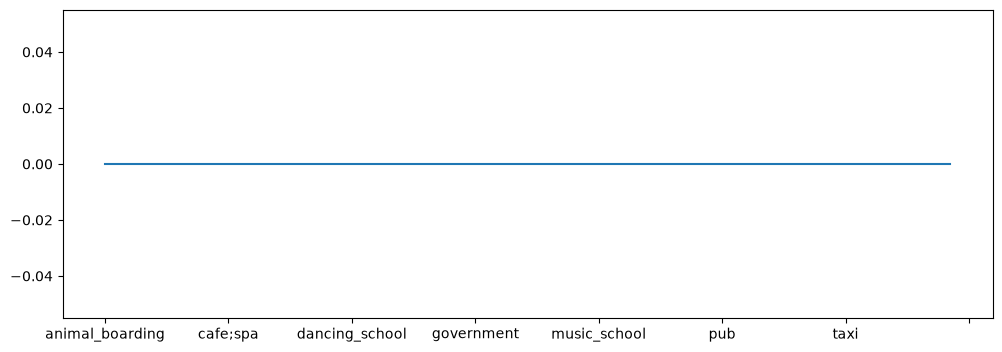

In [47]:
station_list_influence_full[amenity_columns].isna().sum().plot(figsize=(12, 4))

- смотрю что за строчка в которой есть отсутствующие значения

In [48]:
station_list_influence_full[station_list_influence_full['pickup'].isna()]

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,pickup,dropoff,duration_in_minutes
498,31667,2nd & V St SW,38.863743,-77.013817,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,26,1277,NaN,NaN,105617.62


- смотрю есть ли повторение станции

In [38]:
station_list_influence_full[station_list_influence_full['start_station_id'] == 31667]

,start_station_id,station_name,start_lat,start_lng,influence,animal_boarding,animal_shelter,archive,arts_centre,atm,...,vending_machine,veterinary,waste_basket,waste_disposal,watering_place,total_builds,station_work_days,pickup,dropoff,duration_in_minutes
498,31667,2nd & V St SW,38.863743,-77.013817,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,26,1277,NaN,NaN,105617.62
499,31667,2nd & V St SW / James Creek Marina,38.863743,-77.013817,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,26,1277,15030.0,15868.0,105617.62


- принимаю решение что ее просто нужно удалить так как точки полностью совпадают

In [49]:
station_list_influence_full = station_list_influence_full.dropna()

- смотрю результат

In [52]:
station_list_influence_full[core_metrics].isna().sum()

influence              0
total_builds           0
station_work_days      0
pickup                 0
dropoff                0
duration_in_minutes    0
dtype: int64

- записываю dataframe в parquet

In [53]:
table_for_parquet = pa.Table.from_pandas(station_list_influence_full)

In [54]:
pq.write_table(table_for_parquet, '../../data_after_preprocessing/station_list_for_modeling.parquet')